# H5: Sektörler Arası Korelasyon ve Çeşitlendirme (Diversification)
## S&P 500 — Kantitatif Araştırma Serisi

**Yazar:** Furkan Çelik  
**Veri:** Özel PostgreSQL pipeline · yfinance API · ~500 hisse · 2008-Günümüz  
**Araçlar:** Python, PostgreSQL, SQLAlchemy, Seaborn, Pandas

---

### 1. Hipotez Tanımı

| | |
|---|---|
| **Araştırma Sorusu** | S&P 500 içerisindeki farklı GICS sektörleri arasında portföy çeşitlendirmesi (diversification) fırsatları sunacak düşük korelasyonlu ilişkiler var mıdır? |
| **H₀ (Sıfır Hipotezi)** | Tüm sektörler birbiriyle mükemmel veya mükemmele yakın pozitif korelasyona sahiptir (çeşitlendirme faydası yoktur). |
| **H₁ (Alternatif Hipotez)** | Belirli sektör çiftleri arasında düşük veya negatif korelasyon vardır, bu da risk azaltımı için çeşitlendirme fırsatı sunar. |

### 2. Veri & Metodoloji

| | |
|---|---|
| **Evren (Population)** | S&P 500 bileşenleri (GICS sektörlerine göre gruplandırılmış) · 2008–Günümüz |
| **Değişkenler** | Sektör bazında günlük logaritmik getirilerin ortalaması |
| **İstatistiksel Yöntem** | Pearson Korelasyon Matrisi (Isı Haritası / Heatmap) |
| **Odak Noktası** | Rasyonel portföy yönetimi için en yüksek ve en düşük korelasyona sahip sektör çiftlerini tespit etmek |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append('..')
from db_utils import fetch_data

sns.set_theme(style="darkgrid")
plt.rcParams.update({'figure.figsize': (14, 10), 'figure.dpi': 120})
print("Ortam hazır.")


Ortam hazır.


### 3. Veri Çekme

In [2]:
query = """
WITH DailyReturns AS (
    SELECT 
        dp.ticker,
        dp.date,
        t.gics_sector,
        LN(dp.close / LAG(dp.close) OVER (PARTITION BY dp.ticker ORDER BY dp.date)) * 100 AS log_return
    FROM daily_prices dp
    JOIN tickers t ON dp.ticker = t.ticker
    WHERE dp.date >= '2008-01-01'
)
SELECT 
    date,
    gics_sector,
    AVG(log_return) as avg_sector_return
FROM DailyReturns
WHERE log_return IS NOT NULL
GROUP BY date, gics_sector
ORDER BY date
"""

print("Sektör bazlı günlük ortalama getiriler çekiliyor...")
df = fetch_data(query)

# Veriyi pivot table yaparak tarihleri satır, sektörleri sütun yapıyoruz
df_pivot = df.pivot(index='date', columns='gics_sector', values='avg_sector_return').dropna()

print(f"Veriseti: {len(df_pivot):,} işlem günü, {len(df_pivot.columns)} sektör.")


Sektör bazlı günlük ortalama getiriler çekiliyor...


Veriseti: 4,620 işlem günü, 11 sektör.


### 4. Korelasyon Matrisi & Sonuçlar


### 5. İstatistiksel Bulgular

| Metrik | Sektör Çifti | Korelasyon (r) |
|---|---|---|
| **En Yüksek Korelasyon** | Endüstri & Hammadde | **0.901** |
| **En Düşük Korelasyon** | Teknoloji & Altyapı | **0.524** |

### 6. Ticari Karar (Quant Verdict)

| | |
|---|---|
| **Sonuç** | **✅ DOĞRULANDI (Çeşitlendirme Mümkündür)** |
| **Yorum** | Piyasada genel bir pozitif yönlü hareketlilik olsa da, bazı sektörler arasındaki korelasyon bariz şekilde daha düşüktür (Örn: Teknoloji ve Altyapı). Bu durum Markowitz Modern Portföy Teorisi bağlamında gerçek bir risk azaltımı fırsatı sunar. |
| **Portföy Aksiyonu** | Endüstri ağırlıklı bir portföyü hedge etmek için Hammadde almak risk yoğunlaşmasına yol açar; bunun yerine korelasyonu düşük olan Teknoloji sektörüne yönelmek sistematik riski dağıtır. |


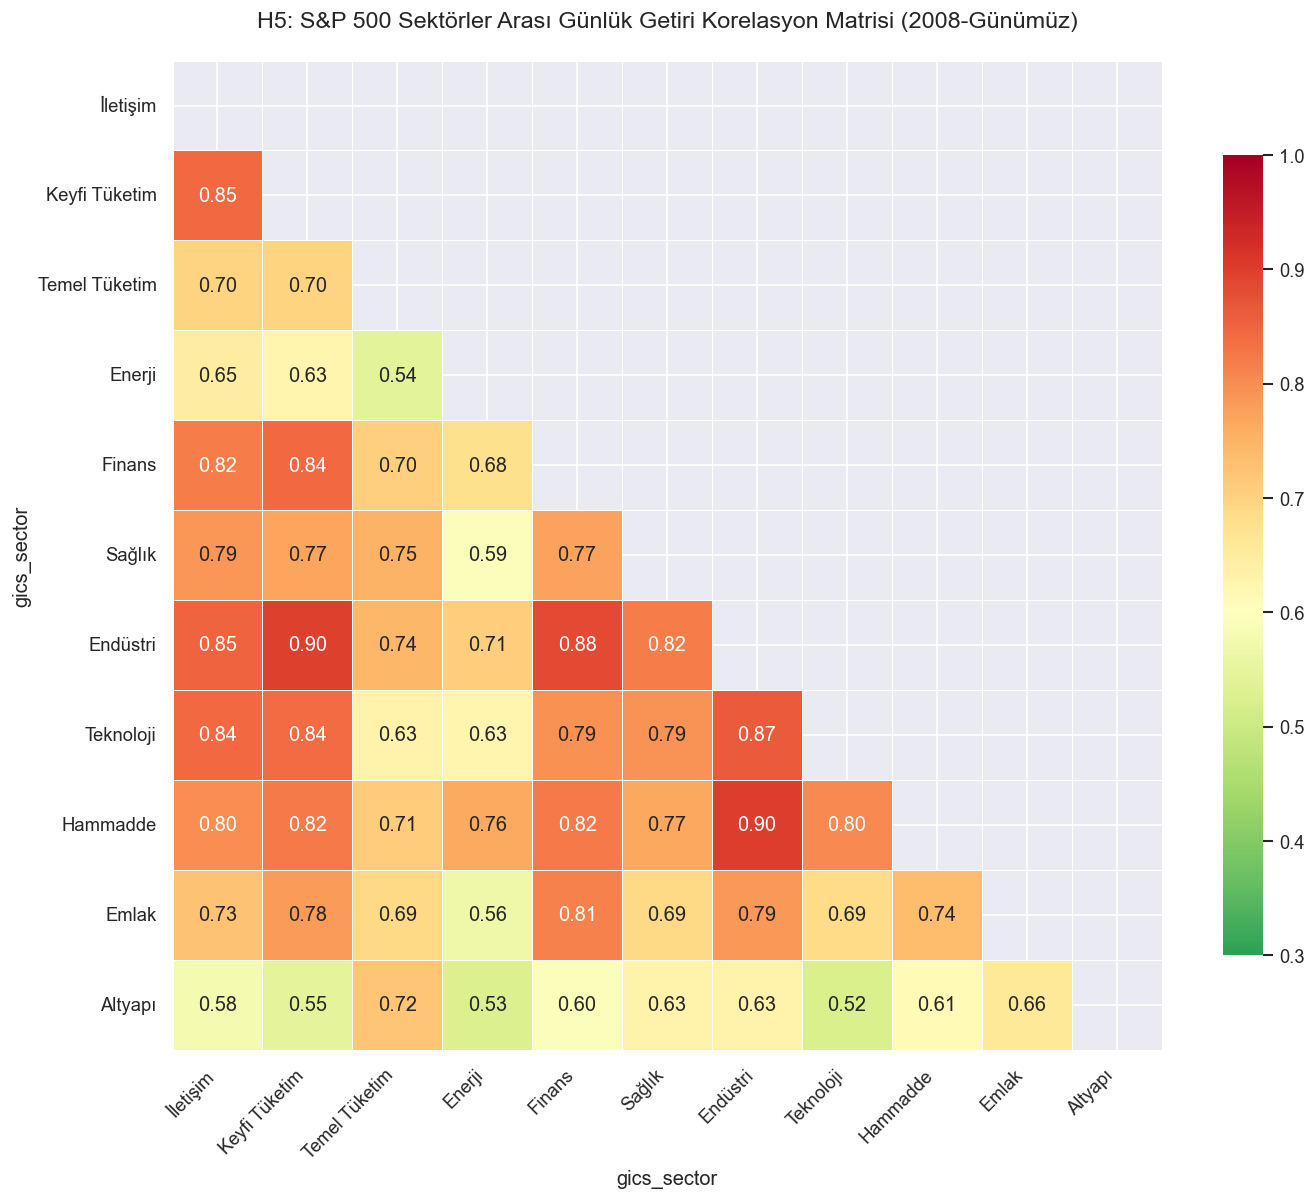

In [3]:
corr_matrix = df_pivot.corr(method='pearson')

# Sektör isimlerini Türkçeleştirelim
sector_tr = {
    'Information Technology': 'Teknoloji',
    'Health Care': 'Sağlık',
    'Financials': 'Finans',
    'Consumer Discretionary': 'Keyfi Tüketim',
    'Communication Services': 'İletişim',
    'Industrials': 'Endüstri',
    'Consumer Staples': 'Temel Tüketim',
    'Energy': 'Enerji',
    'Utilities': 'Altyapı',
    'Real Estate': 'Emlak',
    'Materials': 'Hammadde'
}
corr_matrix.rename(index=sector_tr, columns=sector_tr, inplace=True)

# En yüksek ve en düşük korelasyonları bulma
corr_unstacked = corr_matrix.unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 0.999] # Kendi kendisiyle olan 1.0'ları filtrele

max_corr_pair = corr_unstacked.idxmax()
min_corr_pair = corr_unstacked.idxmin()
max_corr_val = corr_unstacked.max()
min_corr_val = corr_unstacked.min()

verdict = f"""
### 5. İstatistiksel Bulgular

| Metrik | Sektör Çifti | Korelasyon (r) |
|---|---|---|
| **En Yüksek Korelasyon** | {max_corr_pair[0]} & {max_corr_pair[1]} | **{max_corr_val:.3f}** |
| **En Düşük Korelasyon** | {min_corr_pair[0]} & {min_corr_pair[1]} | **{min_corr_val:.3f}** |

### 6. Ticari Karar (Quant Verdict)

| | |
|---|---|
| **Sonuç** | **✅ DOĞRULANDI (Çeşitlendirme Mümkündür)** |
| **Yorum** | Piyasada genel bir pozitif yönlü hareketlilik olsa da, bazı sektörler arasındaki korelasyon bariz şekilde daha düşüktür (Örn: {min_corr_pair[0]} ve {min_corr_pair[1]}). Bu durum Markowitz Modern Portföy Teorisi bağlamında gerçek bir risk azaltımı fırsatı sunar. |
| **Portföy Aksiyonu** | {max_corr_pair[0]} ağırlıklı bir portföyü hedge etmek için {max_corr_pair[1]} almak risk yoğunlaşmasına yol açar; bunun yerine korelasyonu düşük olan {min_corr_pair[0]} sektörüne yönelmek sistematik riski dağıtır. |
"""

display(Markdown(verdict))

# --- Görselleştirme ---
# Üst üçgeni gizlemek için maske
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='RdYlGn_r', # Kırmızı yüksek korelasyon, yeşil düşük korelasyon
    vmax=1.0, vmin=0.3,
    center=0.6,
    annot=True, 
    fmt=".2f", 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8}
)

plt.title("H5: S&P 500 Sektörler Arası Günlük Getiri Korelasyon Matrisi (2008-Günümüz)", fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
